In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.stats import norm
from scipy.optimize import brentq

In [53]:
rng = np.random.default_rng(42)
n = 500
X = rng.normal(size=n)
y = rng.choice([0, 1], size=n, p=[0.84, 0.16])

### Linear

Correlation before: 0.47
Correlation after: 0.44


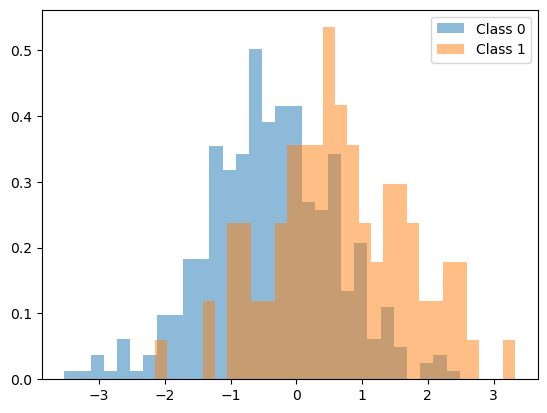

In [54]:
XY = rng.multivariate_normal(mean=[0, 0], cov=[[1.0, 0.5], [0.5, 1.0]], size=n)
X = XY[:, 0]
Y = XY[:, 1]

print(f"Correlation before: {np.corrcoef(X, Y)[0, 1]:.2f}")

X[y==1] += 0.5
X[y==0] -= 0.5

print(f"Correlation after: {np.corrcoef(X, Y)[0, 1]:.2f}")

plt.hist(X[y==0], bins=30, alpha=0.5, label='Class 0', density=True)
plt.hist(X[y==1], bins=30, alpha=0.5, label='Class 1', density=True)
plt.legend()

### U-shaped

Correlation before: 0.50
Correlation after: 0.50


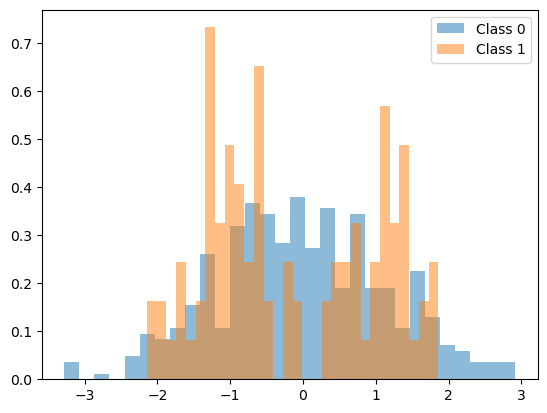

In [55]:
XY = rng.multivariate_normal(mean=[0, 0], cov=[[1.0, 0.5], [0.5, 1.0]], size=n)
X = XY[:, 0]
Y = XY[:, 1]

print(f"Correlation before: {np.corrcoef(X, Y)[0, 1]:.2f}")

def mixture_cdf(x, mus=(-0.5, 0.5), sigmas=(1.0, 1.0), weights=(0.5, 0.5)):
    return sum(w * norm.cdf(x, loc=m, scale=s)
               for w, m, s in zip(weights, mus, sigmas))

def mixture_ppf_scalar(u, mus, sigmas, weights, lo=-20.0, hi=20.0, xtol=1e-12):
    return brentq(lambda x: mixture_cdf(x, mus, sigmas, weights) - u,
                  lo, hi, xtol=xtol)

def normal_to_mixture(X, mus=(-0.5, 0.5), sigmas=(1.0, 1.0), weights=(0.5, 0.5)):
    U = norm.cdf(X)                       # N(0,1) -> U(0,1)
    U = np.clip(U, 1e-15, 1 - 1e-15)      # guard against ±inf
    return np.array([mixture_ppf_scalar(u, mus, sigmas, weights) for u in U])

a = 1
sigma = 0.5
X[y==0] *= np.sqrt(a**2 +sigma**2)
X[y==1] = normal_to_mixture(X[y==1], mus=(-a, a), sigmas=(sigma, sigma), weights=(0.5, 0.5))

print(f"Correlation after: {np.corrcoef(X, Y)[0, 1]:.2f}")

plt.hist(X[y==0], bins=30, alpha=0.5, label='Class 0', density=True)
plt.hist(X[y==1], bins=30, alpha=0.5, label='Class 1', density=True)
plt.legend()

### XOR_pair

Correlation before (X, Y): 0.47
Correlation before (X, Z): -0.01
Correlation before (Y, Z): -0.02
Correlation before (Z, Z2): 0.52
Correlation before (Z, Z3): 0.36
Correlation after (X, Y): 0.47
Correlation after (X, Z): 0.30
Correlation after (Y, Z): 0.10
Correlation after (Z, Z2): 0.53
Correlation after (Z, Z3): 0.39
Correlation after (X, Z2): -0.04


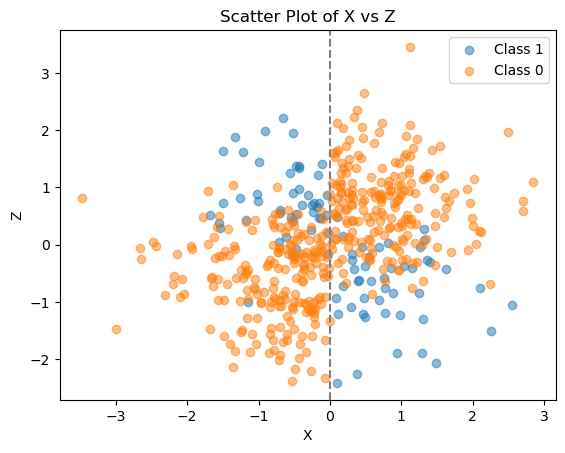

In [ ]:
XYZ = rng.multivariate_normal(mean=[0, 0, 0, 0, 0], cov=[[1.0, 0.5, 0.0, 0.0, 0.0], [0.5, 1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.5, 0.4], [0.0, 0.0, 0.5, 1.0, 0.4], [0.0, 0.0, 0.4, 0.4, 1.0]], size=n)
X = XYZ[:, 0]
Y = XYZ[:, 1]
Z = XYZ[:, 2]
Z2 = XYZ[:, 3]
Z3 = XYZ[:, 4]

print(f"Correlation before (X, Y): {np.corrcoef(X, Y)[0, 1]:.2f}")
print(f"Correlation before (X, Z): {np.corrcoef(X, Z)[0, 1]:.2f}")
print(f"Correlation before (Y, Z): {np.corrcoef(Y, Z)[0, 1]:.2f}")
print(f"Correlation before (Z, Z2): {np.corrcoef(Z, Z2)[0, 1]:.2f}")
print(f"Correlation before (Z, Z3): {np.corrcoef(Z, Z3)[0, 1]:.2f}")

def inject_xor_topk(
    cols: np.ndarray,
    y: np.ndarray,
    idx_a: int,
    idx_b: int,
    effect_size: float,
    rng: np.random.Generator,
    k: int = 1,
) -> None:
    n, d = cols.shape
    Z = cols[:, idx_b]

    # rank all other columns by |corr with Z|, keep top-k
    others = np.array([j for j in range(d) if j != idx_b])
    Zc = Z - Z.mean()
    Cc = cols[:, others] - cols[:, others].mean(axis=0)
    num = Zc @ Cc
    den = np.linalg.norm(Zc) * np.linalg.norm(Cc, axis=0) + 1e-12
    abs_corr = np.abs(num / den)
    partners = others[np.argsort(abs_corr)[-k:]]

    P = cols[:, partners]
    beta, *_ = np.linalg.lstsq(P, Z, rcond=None)
    fitted = P @ beta
    residual = Z - fitted

    sign_a = np.sign(cols[:, idx_a]); sign_a[sign_a == 0] = 1.0
    flip = np.where(y == 1, -1.0, 1.0)
    target_sign = sign_a * flip
    p = 0.5 + 0.5 * np.clip(effect_size, 0.0, 1.0)
    follow = rng.uniform(size=n) < p
    final_sign = np.where(follow, target_sign, -target_sign)

    cols[:, idx_b] = fitted + final_sign * np.abs(residual)

inject_xor_topk(XYZ, y, idx_a=0, idx_b=2,
                effect_size=1, rng=rng, k=3)


print(f"Correlation after (X, Y): {np.corrcoef(XYZ[:, 0], XYZ[:, 1])[0, 1]:.2f}")
print(f"Correlation after (X, Z): {np.corrcoef(XYZ[:, 0], XYZ[:, 2])[0, 1]:.2f}")
print(f"Correlation after (Y, Z): {np.corrcoef(XYZ[:, 1], XYZ[:, 2])[0, 1]:.2f}")
print(f"Correlation after (Z, Z2): {np.corrcoef(XYZ[:, 2], XYZ[:, 3])[0, 1]:.2f}")
print(f"Correlation after (Z, Z3): {np.corrcoef(XYZ[:, 2], XYZ[:, 4])[0, 1]:.2f}")

plt.scatter(XYZ[y == 1, 0], XYZ[y == 1, 2], alpha=0.5, label='Class 1')
plt.scatter(XYZ[y == 0, 0], XYZ[y == 0, 2], alpha=0.5, label='Class 0')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel("X")
plt.ylabel("Z")
plt.title("Scatter Plot of X vs Z")
plt.legend()
plt.show()


### Bounded Varaince

Correlation before: 0.45
Correlation after: 0.46
1.0265368633359124 1.7194943648727194


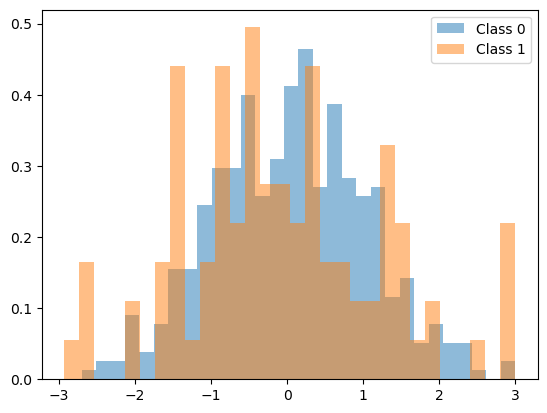

In [86]:
XY = rng.multivariate_normal(mean=[0, 0], cov=[[1.0, 0.5], [0.5, 1.0]], size=n)
X = XY[:, 0]
Y = XY[:, 1]

print(f"Correlation before: {np.corrcoef(X, Y)[0, 1]:.2f}")

a = 0.3
X[y== 1] *= a+1
X = np.clip(X, -3, 3)

print(f"Correlation after: {np.corrcoef(X, Y)[0, 1]:.2f}")

print(np.var(X[y==0]), np.var(X[y==1]))

plt.hist(X[y==0], bins=30, alpha=0.5, label='Class 0', density=True)
plt.hist(X[y==1], bins=30, alpha=0.5, label='Class 1', density=True)
plt.legend()

### Threshold

Correlation before: 0.50
Correlation after: 0.43


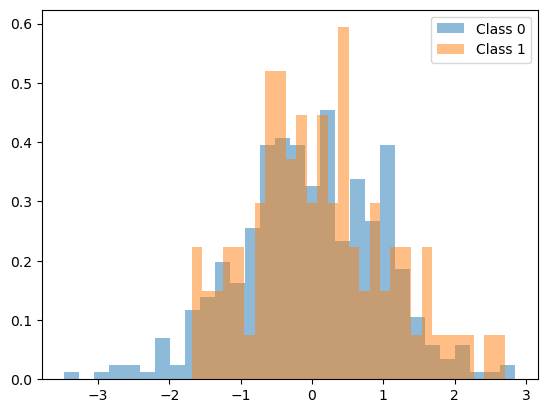

In [97]:
XY = rng.multivariate_normal(mean=[0, 0], cov=[[1.0, 0.5], [0.5, 1.0]], size=n)
X = XY[:, 0]
Y = XY[:, 1]

print(f"Correlation before: {np.corrcoef(X, Y)[0, 1]:.2f}")

def inject_threshold_signal(
    cols: np.ndarray,
    y: np.ndarray,
    idx: int,
    tau: float,
    effect_size: float,
    rng: np.random.Generator,
) -> None:
    """
    Reshuffle X = cols[:, idx] above tau so that higher X values are
    preferentially paired with y=1. Below tau, X is left untouched.
    Marginal of X is preserved exactly (it's a within-subset permutation).
    """
    X = cols[:, idx]
    above = np.where(X > tau)[0]
    if above.size < 2:
        return  # nothing to permute

    # noisy score: higher when y=1, noisier when effect_size is small
    score = 2*effect_size * y[above] + rng.standard_normal(above.size)

    # sort indices: highest X to highest score
    #x_sorted_pos = above[np.argsort(X[above])]          # ascending X positions
    #score_order  = np.argsort(score)                    # ascending score positions
    #new_X_above = np.empty(above.size)
    #new_X_above[above[score_order]] = X[x_sorted_pos]   # rank-match
    # NB: indexing trick — write sorted X values into the positions ordered by score

    # cleaner equivalent without the index gymnastics:
    sorted_X_vals = np.sort(X[above])                   # ascending
    rank_of_score = np.argsort(np.argsort(score))       # 0..k-1 ranks
    cols[above, idx] = sorted_X_vals[rank_of_score]

inject_threshold_signal(XYZ, y, idx=0, tau=0.5, effect_size=0.3, rng=rng)

print(f"Correlation after: {np.corrcoef(XYZ[:, 0], XYZ[:, 1])[0, 1]:.2f}")

plt.hist(XYZ[y==0, 0], bins=30, alpha=0.5, label='Class 0', density=True)
plt.hist(XYZ[y==1, 0], bins=30, alpha=0.5, label='Class 1', density=True)
plt.legend()